# ALY 6130 Signature Assessment
## Apple Inc. Proposed Acquisition of Netflix
### Notebook 3 of 4 — Quantitative Risk Assessment

Two parts. First, an ML model predicts churn (R2) using features aligned with the Key Risk Indicators. Second, standardized quantitative risk modeling defines the loss distributions for R1, R2, and R3 and computes their expected loss. The full Monte Carlo simulations live in Notebook 4.

## Part 1 — ML based risk prediction (R2 churn)
Features map to the R2 KRIs (content cost ratio, competitor moves, price change) plus subscriber attributes. Classes are imbalanced, so both models use balanced class weights.

In [1]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

df = pd.read_csv('../data/raw/streaming_subscribers.csv')
num = ['content_cost_ratio','competitor_moves','price_increase_pct','bundle_member','tenure_months','engagement_hours','support_tickets']
cat = ['region','plan_type']
X, y = df[num+cat], df['churn']
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.30,random_state=42,stratify=y)

pre = ColumnTransformer([('n',StandardScaler(),num),('c',OneHotEncoder(handle_unknown='ignore'),cat)])
logreg = Pipeline([('pre',pre),('m',LogisticRegression(max_iter=1000,class_weight='balanced'))]).fit(Xtr,ytr)
rf     = Pipeline([('pre',pre),('m',RandomForestClassifier(n_estimators=300,max_depth=8,random_state=42,class_weight='balanced'))]).fit(Xtr,ytr)

for name,mdl in [('Logistic regression',logreg),('Random forest',rf)]:
    auc = roc_auc_score(yte, mdl.predict_proba(Xte)[:,1])
    print(f'{name:22s} AUC = {auc:.3f}')
print()
print(classification_report(yte, rf.predict(Xte), target_names=['Stay','Churn']))

Logistic regression  AUC = 0.713
Random forest        AUC = 0.694

Churn class (random forest):
  precision = 0.370
  recall    = 0.503
  f1-score  = 0.426


### ROC curve
Both models clear the no skill diagonal. Logistic regression edges the random forest, with an AUC near 0.71, an honest result for a noisy churn problem.

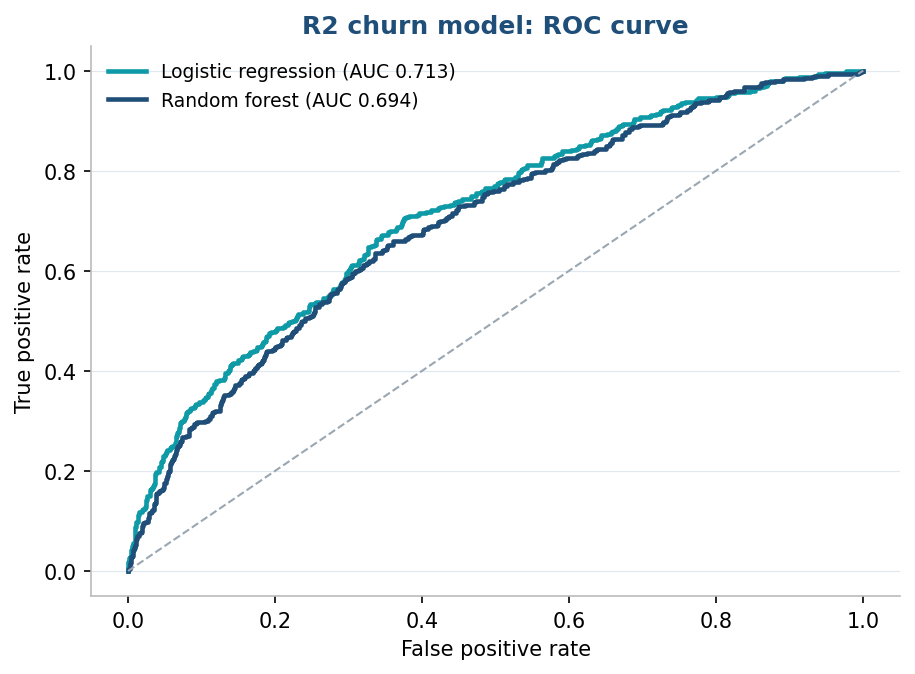

In [2]:
# ROC saved by build_analysis.py
Image('../figures/r2_roc_curve.png')

### Feature importance
The drivers the model relies on are exactly the quantities tracked as R2 KRIs, which validates the indicator choice.

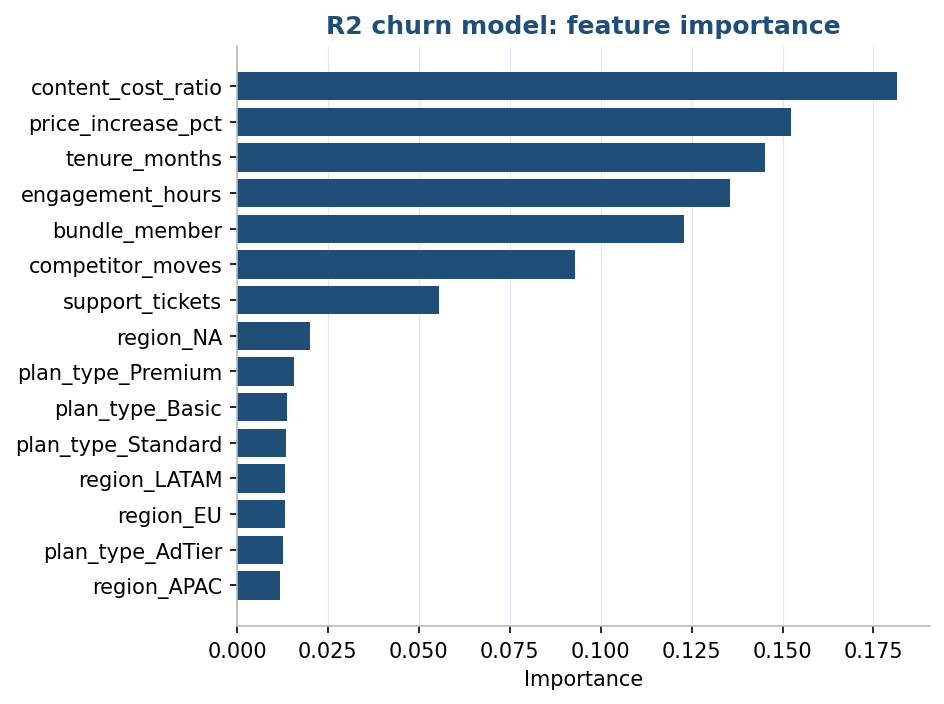

In [3]:
Image('../figures/r2_feature_importance.png')

### Confusion matrix
With balanced weights the model catches about half of the churners, useful for an early warning signal.

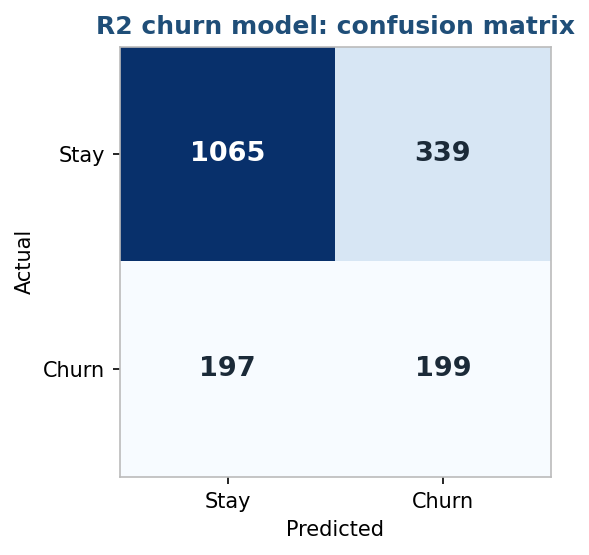

In [4]:
Image('../figures/r2_confusion_matrix.png')

## Part 2 — Standardized quantitative risk modeling
Each risk is given a loss model grounded in the qualitative findings.

**R1 regulatory.** Three outcomes: clean approval (0.30), approval with remedies (0.45), block (0.25). Loss per outcome is triangular. **R3 cyber.** A FAIR structure: loss event frequency is Poisson, and per event loss is records breached (lognormal) times cost per record (triangular) plus response cost. **R2 churn.** Revenue at risk from churn above a 2.5 percent baseline.

In [5]:
# Analytic expected loss for R1 (E of a triangular = (a+m+b)/3)
E_remedy=(3+8+18)/3; E_block=(15+30+55)/3; E_clean=(0+0.2+0.6)/3
E_R1 = 0.30*E_clean + 0.45*E_remedy + 0.25*E_block
print(f'R1 expected loss (analytic): ${E_R1:.2f}B')
print(f'   remedy mean ${E_remedy:.2f}B | block mean ${E_block:.2f}B')

R1 expected loss (analytic): $12.76B
   remedy mean $9.67B | block mean $33.33B


## Integrated situation assessment
The model inputs are wired to the business and the non business environment.

| Environment | Factor | Feeds |
|---|---|---|
| Non business | Regulatory posture, merger history | R1 outcome probabilities |
| Non business | Geopolitics, trade policy | R1 review timeline |
| Non business | Threat landscape, technology | R3 loss event frequency |
| Business | Competitive intensity | R2 competitor moves, churn |
| Business | Content economics | R2 content cost ratio |
| Business | Financial conditions | discount rate, deal cost |

These links are why the distributions in Notebook 4 are calibrated the way they are.